# Credit scoring — versione rivista

**Caso di studio:** *Pro National Bank* vuole decidere in automatico a quali richiedenti concedere una carta di credito,
e spiegare il motivo di ogni rifiuto.
**Dati:** 338.427 richieste, 17 caratteristiche anagrafiche e lavorative, target `TARGET` (1 = cliente affidabile, 8,8%).

La prima versione confrontava regressione logistica, SVM e Random Forest (ROC AUC 0.978) e generava le "motivazioni del rifiuto"
dalle feature importance. Rivedendola ho trovato alcuni errori, ma soprattutto una proprietà dei dati che cambia la soluzione:
**il target segue tre soglie** su reddito, età e anzianità lavorativa. Il modello migliore diventa così un piccolo albero decisionale,
accurato quanto la Random Forest ma leggibile e capace di spiegare ogni decisione.

---
### Note di revisione
| # | Problema nella versione precedente | Correzione |
|---|---|---|
| 1 | `df.drop("CNT_FAM_MEMBERS", axis=1)` senza assegnazione: la colonna non veniva mai rimossa | rimossa davvero (quasi duplicato di `CNT_CHILDREN`) |
| 2 | SMOTE calcolato, poi il modello veniva riaddestrato senza: codice inutilizzato | rimosso; lo sbilanciamento si gestisce con metriche adatte (PR AUC) e con la soglia |
| 3 | Mediana dell'anzianità e pulizia calcolate su tutto il dataset prima dello split | preprocessing in una `Pipeline` addestrata solo sul training |
| 4 | Motivazioni del rifiuto prese dalle feature importance **globali**: le stesse 3 per ogni cliente, senza dire quale requisito manca | spiegazione **per cliente**: quale soglia non è rispettata e di quanto |
| 5 | Soglia 0.5 e fasce 0.2 / 0.4 fissate a mano | soglia scelta sul validation set e fasce giustificate dalla distribuzione delle probabilità |
| 6 | Valutazione su un solo split, solo ROC AUC | cross-validation a 5 fold, PR AUC e Brier score, test set tenuto da parte |
| 7 | `CODE_GENDER` usato come variabile del modello | escluso: nella UE il credit scoring è un sistema "ad alto rischio" (AI Act) e il genere non deve incidere; verifica dei tassi di approvazione per genere |
| 8 | `FLAG_MOBIL` costante; anzianità dei pensionati codificata come +365.243 giorni | colonna costante eliminata; flag `OCCUPATO` e anzianità in anni |

In [12]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss, f1_score,
                             precision_score, recall_score, confusion_matrix, precision_recall_curve)
warnings.filterwarnings('ignore', category=FutureWarning)

DATA_URL     = 'https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_scoring.csv'
DRIVE_FOLDER = '/content/drive/MyDrive/modelli_addestrati/credit_scoring'
SEED = 0

try:
    from google.colab import drive
    IN_COLAB = True
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except ImportError:
    IN_COLAB = False
OUT = DRIVE_FOLDER if IN_COLAB else '/tmp/credit_scoring'
os.makedirs(OUT, exist_ok=True)

## 1. Dati

In [13]:
raw = pd.read_csv(DATA_URL)
print(raw.shape)
print('Righe con valori mancanti (escluso OCCUPATION_TYPE):', raw.drop(columns='OCCUPATION_TYPE').isna().any(axis=1).sum())
print('FLAG_MOBIL valori distinti:', raw.FLAG_MOBIL.dropna().unique())
print('Target:', raw.TARGET.value_counts().to_dict(), f'-> {raw.TARGET.mean():.1%} affidabili')
raw.head(3).T

(338427, 19)
Righe con valori mancanti (escluso OCCUPATION_TYPE): 1
FLAG_MOBIL valori distinti: [1.]
Target: {0: 308705, 1: 29722} -> 8.8% affidabili


,0,1,2
ID,5008804,5008805,5008806
CODE_GENDER,M,M,M
FLAG_OWN_CAR,Y,Y,Y
FLAG_OWN_REALTY,Y,Y,Y
CNT_CHILDREN,0,0,0
AMT_INCOME_TOTAL,424380.57,421593.52,110958.51
NAME_INCOME_TYPE,Working,Working,Working
NAME_EDUCATION_TYPE,Higher education,Higher education,Secondary / secondary special
NAME_FAMILY_STATUS,Civil marriage,Civil marriage,Married
NAME_HOUSING_TYPE,Rented apartment,Rented apartment,House / apartment


### Preparazione delle variabili
Una sola funzione, usata identica nel notebook e nella demo:
- **età** e **anzianità lavorativa in anni** al posto dei giorni negativi; chi non lavora (pensionati, codificati con +365.243 giorni) ha `OCCUPATO = 0` e anzianità 0;
- variabili binarie Y/N → 1/0; `OCCUPATION_TYPE` mancante → categoria `Non indicato`;
- eliminate `ID`, `FLAG_MOBIL` (costante) e `CNT_FAM_MEMBERS` (quasi uguale a `CNT_CHILDREN` + coniuge);
- `CODE_GENDER` resta nel dataframe **solo per l'analisi di equità**, non entra nel modello.

In [14]:
NUM = ['REDDITO', 'ETA', 'ANZIANITA', 'CNT_CHILDREN']
BIN = ['OCCUPATO', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
CAT = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
FEATURES = NUM + BIN + CAT

def prepara(df):
    # Trasforma i dati grezzi (stesso formato del CSV) nelle variabili del modello.
    out = pd.DataFrame(index=df.index)
    out['REDDITO'] = df['AMT_INCOME_TOTAL'].astype(float)
    out['ETA'] = -df['DAYS_BIRTH'] / 365.25
    occupato = df['DAYS_EMPLOYED'] <= 0
    out['OCCUPATO'] = occupato.astype(int)
    out['ANZIANITA'] = np.where(occupato, -df['DAYS_EMPLOYED'] / 365.25, 0.0)
    out['CNT_CHILDREN'] = df['CNT_CHILDREN']
    for c in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        out[c] = (df[c] == 'Y').astype(int)
    for c in ['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']:
        out[c] = df[c].astype(int)
    for c in CAT:
        out[c] = df[c].fillna('Non indicato').astype(str).astype(object)
    return out[FEATURES]

data = raw.dropna(subset=['DAYS_BIRTH']).reset_index(drop=True)      # 1 riga incompleta
X_all, y_all, gender_all = prepara(data), data['TARGET'].to_numpy(dtype=int), data['CODE_GENDER'].to_numpy(dtype=object)
print(X_all.shape); X_all.describe().T.round(2)

(338426, 15)


,count,mean,std,min,25%,50%,75%,max
REDDITO,338426.0,187668.90,110786.25,25548.98,121230.58,162855.65,225208.17,7071015.83
ETA,338426.0,43.80,11.48,20.71,34.27,42.77,53.30,72.93
ANZIANITA,338426.0,5.98,6.60,0.00,1.03,4.06,8.53,49.21
CNT_CHILDREN,338426.0,0.43,0.73,0.00,0.00,0.00,1.00,19.00
OCCUPATO,338426.0,0.83,0.38,0.00,1.00,1.00,1.00,1.00
FLAG_OWN_CAR,338426.0,0.37,0.48,0.00,0.00,0.00,1.00,1.00
FLAG_OWN_REALTY,338426.0,0.68,0.47,0.00,0.00,1.00,1.00,1.00
FLAG_WORK_PHONE,338426.0,0.21,0.41,0.00,0.00,0.00,0.00,1.00
FLAG_PHONE,338426.0,0.29,0.46,0.00,0.00,0.00,1.00,1.00
FLAG_EMAIL,338426.0,0.11,0.31,0.00,0.00,0.00,0.00,1.00


## 2. Esplorazione: da cosa dipende il target?
Guardiamo la quota di clienti affidabili al variare di reddito, età e anzianità.

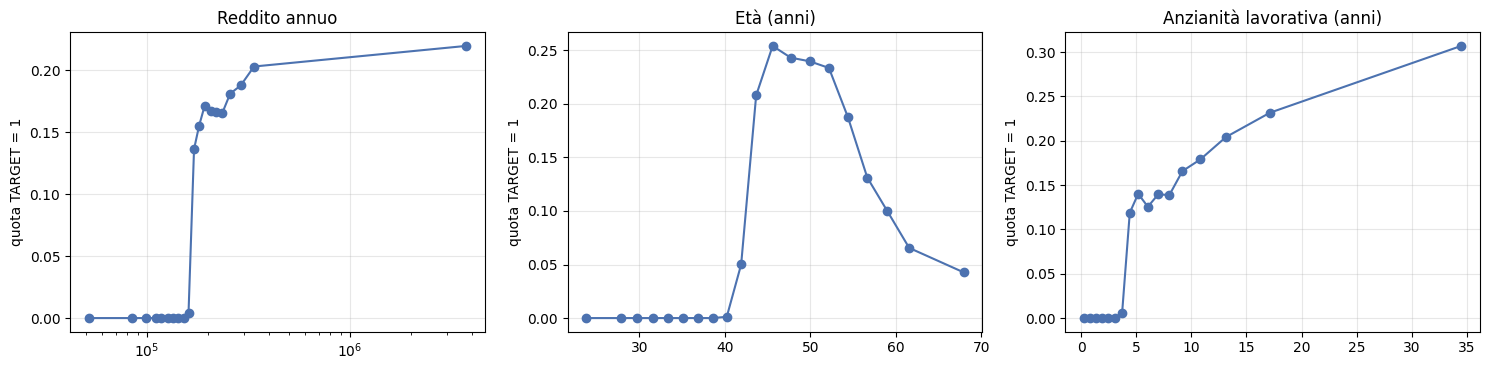

      Pensioner     Working  Commercial associate  State servant  Student
mean        0.0       0.095                 0.121          0.134    0.176
size    57841.0  174365.000             78090.000      28113.000   17.000 

      Waiters/barmen staff  Non indicato  IT staff  Low-skill Laborers  Cooking staff  Sales staff  Secretaries   Laborers  Security staff  Core staff  Cleaning staff    Drivers  Private service staff  High skill tech staff  Accountants  Medicine staff  HR staff  Realty agents   Managers
mean                 0.027         0.044     0.046               0.054          0.064        0.065         0.07      0.097           0.097         0.1             0.1      0.108                  0.116                  0.119        0.132           0.137     0.153          0.153      0.179
size              1245.000    103341.000   436.000            1714.000       6248.000    31652.000      1577.00  60146.000        6218.000     33527.0          4594.0  20020.000               2787.0

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col, bins, label in [(axes[0], 'REDDITO', 20, 'Reddito annuo'),
                             (axes[1], 'ETA', 20, 'Età (anni)'),
                             (axes[2], 'ANZIANITA', 20, 'Anzianità lavorativa (anni)')]:
    q = pd.qcut(X_all[col], bins, duplicates='drop')
    rate = pd.Series(y_all).groupby(q.values, observed=True).mean()
    centers = [iv.mid for iv in rate.index]
    ax.plot(centers, rate.values, marker='o', color='#4C72B0')
    ax.set_title(label); ax.set_ylabel('quota TARGET = 1'); ax.grid(alpha=.3)
axes[0].set_xscale('log')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'target_vs_variabili.png'), dpi=140); plt.show()

for col in ['NAME_INCOME_TYPE', 'OCCUPATION_TYPE']:
    print(pd.Series(y_all).groupby(X_all[col].values).agg(['mean', 'size']).round(3).sort_values('mean').T.to_string(), '\n')

Il grafico mostra **gradini netti**: sotto circa 160 mila di reddito, sotto i 40 anni di età e con meno di 4 anni di anzianità
la quota di affidabili è **esattamente zero**. Sopra le soglie l'effetto diventa graduale: cresce con anzianità e reddito e cala dopo i 55 anni.
I pensionati (57.841) sono tutti a 0 perché non hanno anzianità lavorativa. È il comportamento tipico di un target costruito su **requisiti minimi
di policy** più una valutazione più sfumata, e le soglie sono esattamente ciò che un albero decisionale sa rappresentare.

## 3. Split e protocollo
- **Test set** (20%) messo da parte fino alla fine.
- Sul restante 80%: **cross-validation stratificata a 5 fold** per confrontare i modelli.
- Metriche: **ROC AUC** (ordinamento), **PR AUC** (più informativa con l'8,8% di positivi), **Brier score** (qualità delle probabilità, più basso = meglio).

In [16]:
X_tr, X_te, y_tr, y_te, g_tr, g_te = train_test_split(X_all, y_all, gender_all, test_size=0.2, stratify=y_all, random_state=SEED)
print(f'train {len(X_tr):,} · test {len(X_te):,} · positivi train {y_tr.mean():.3%} test {y_te.mean():.3%}')

def preprocessore(scala=False):
    num = Pipeline([('log', FunctionTransformer(np.log1p)), ('sc', StandardScaler())]) if scala else 'passthrough'
    return ColumnTransformer([
        ('num', num, NUM),
        ('bin', 'passthrough', BIN),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False), CAT),
    ], verbose_feature_names_out=False)

modelli = {
    'Regressione logistica': Pipeline([('prep', preprocessore(scala=True)), ('clf', LogisticRegression(max_iter=2000, C=1.0))]),
    'Random Forest (300 alberi)': Pipeline([('prep', preprocessore()), ('clf', RandomForestClassifier(300, min_samples_leaf=5, n_jobs=-1, random_state=SEED))]),
    'Gradient Boosting (HGB)': Pipeline([('prep', preprocessore()), ('clf', HistGradientBoostingClassifier(max_iter=300, random_state=SEED))]),
}
for d in [2, 3, 4, 5, 6, 8]:
    modelli[f'Albero, profondità {d}'] = Pipeline([('prep', preprocessore()), ('clf', DecisionTreeClassifier(max_depth=d, min_samples_leaf=50, random_state=SEED))])

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
righe = []
for nome, m in modelli.items():
    t0 = time.time()
    r = cross_validate(m, X_tr, y_tr, cv=cv, n_jobs=1, scoring={'roc': 'roc_auc', 'ap': 'average_precision', 'brier': 'neg_brier_score'})
    righe.append({'modello': nome, 'ROC AUC': r['test_roc'].mean(), '± ': r['test_roc'].std(), 'PR AUC': r['test_ap'].mean(),
                  'Brier': -r['test_brier'].mean(), 'secondi': time.time() - t0})
cv_res = pd.DataFrame(righe).set_index('modello')
cv_res.to_csv(os.path.join(OUT, 'cv_modelli.csv'))
cv_res.style.format({'ROC AUC': '{:.4f}', '± ': '{:.4f}', 'PR AUC': '{:.4f}', 'Brier': '{:.4f}', 'secondi': '{:.0f}'})

train 270,740 · test 67,686 · positivi train 8.783% test 8.782%


,ROC AUC,±,PR AUC,Brier,secondi
modello,,,,,
Regressione logistica,0.9438,0.0003,0.5422,0.0527,21
Random Forest (300 alberi),0.9781,0.0004,0.6903,0.0304,417
Gradient Boosting (HGB),0.9783,0.0003,0.6898,0.0298,75
"Albero, profondità 2",0.9086,0.0013,0.3511,0.0574,12
"Albero, profondità 3",0.9726,0.0009,0.6547,0.0313,13
"Albero, profondità 4",0.9766,0.0006,0.6795,0.0304,15
"Albero, profondità 5",0.9775,0.0004,0.6859,0.0302,15
"Albero, profondità 6",0.9778,0.0003,0.6892,0.0301,16
"Albero, profondità 8",0.9776,0.0003,0.6920,0.0302,16


Già con profondità 3 un singolo albero arriva a ROC AUC 0.973; con profondità 6 raggiunge Random Forest e Gradient Boosting
(differenza di PR AUC inferiore a 0.003). Aggiungere centinaia di alberi non porta quasi nulla.
La regressione logistica resta indietro perché una soglia ("reddito almeno X") non è una relazione lineare.

## 4. Il tetto delle prestazioni
Se il target è "requisiti minimi + qualcos'altro", conviene capire **cosa succede tra chi rispetta i requisiti**.
Estraggo le regole da un albero a 3 variabili e misuro quanto un modello riesce a distinguere i clienti *all'interno* della zona idonea.

In [17]:
t3 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=SEED).fit(X_tr[['REDDITO', 'ETA', 'ANZIANITA']], y_tr)
print(export_text(t3, feature_names=['REDDITO', 'ETA', 'ANZIANITA'], decimals=1, show_weights=True))

# Soglie ricavate dai dati: il valore minimo, tra i clienti con TARGET = 1, di ciascuna variabile
SOGLIE = {c: float(X_tr.loc[y_tr == 1, c].min()) for c in ['REDDITO', 'ETA', 'ANZIANITA']}
print('Soglie minime osservate tra gli affidabili:', {k: round(v, 2) for k, v in SOGLIE.items()})

def idoneo(X):
    return (X['REDDITO'] >= SOGLIE['REDDITO']) & (X['ETA'] >= SOGLIE['ETA']) & (X['ANZIANITA'] >= SOGLIE['ANZIANITA'])

ok_tr = idoneo(X_tr).values
print(f'\nClienti idonei nel training: {ok_tr.mean():.1%} · TARGET=1 fuori dalla zona idonea: {y_tr[~ok_tr].sum()} · '
      f'quota di affidabili dentro la zona: {y_tr[ok_tr].mean():.1%}')

# Dentro la zona idonea, le altre variabili aiutano a prevedere il target?
hgb = modelli['Gradient Boosting (HGB)']
r_in = cross_validate(hgb, X_tr[ok_tr], y_tr[ok_tr], cv=cv, scoring='roc_auc')
print(f'ROC AUC del Gradient Boosting SOLO tra i clienti idonei: {r_in["test_score"].mean():.3f}  (0.5 = come tirare una moneta)')

|--- REDDITO <= 164783.9
|   |--- REDDITO <= 162736.7
|   |   |--- REDDITO <= 161242.7
|   |   |   |--- weights: [132875.0, 26.0] class: 0
|   |   |--- REDDITO >  161242.7
|   |   |   |--- weights: [2208.0, 26.0] class: 0
|   |--- REDDITO >  162736.7
|   |   |--- ANZIANITA <= 13.6
|   |   |   |--- weights: [1493.0, 44.0] class: 0
|   |   |--- ANZIANITA >  13.6
|   |   |   |--- weights: [165.0, 44.0] class: 0
|--- REDDITO >  164783.9
|   |--- ETA <= 42.5
|   |   |--- ETA <= 41.8
|   |   |   |--- weights: [65590.0, 114.0] class: 0
|   |   |--- ETA >  41.8
|   |   |   |--- weights: [2519.0, 319.0] class: 0
|   |--- ETA >  42.5
|   |   |--- ANZIANITA <= 4.1
|   |   |   |--- weights: [30225.0, 79.0] class: 0
|   |   |--- ANZIANITA >  4.1
|   |   |   |--- weights: [11887.0, 23126.0] class: 1

Soglie minime osservate tra gli affidabili: {'REDDITO': 156890.64, 'ETA': 40.36, 'ANZIANITA': 3.89}

Clienti idonei nel training: 17.1% · TARGET=1 fuori dalla zona idonea: 0 · quota di affidabili dentro

Le tre soglie separano perfettamente chi **non può** essere affidabile: fuori dalla zona idonea non c'è nessun `TARGET = 1`.
Dentro la zona, circa metà dei clienti è affidabile e il modello riesce solo in parte a distinguerli (ROC AUC intorno a 0.76):
le variabili disponibili spiegano una parte della differenza, non tutta. Per questo **tutti** i modelli non banali si fermano allo stesso valore
(~0.978 di ROC AUC): è il limite dei dati, non degli algoritmi. Per fare meglio servono informazioni nuove, per esempio lo storico dei pagamenti.

## 5. Modello finale: albero decisionale (profondità scelta in CV)

In [18]:
alberi = cv_res.loc[cv_res.index.str.startswith('Albero')]
best_depth = int(alberi['PR AUC'].idxmax().split()[-1])
# a parità di prestazioni (entro 0.005 di PR AUC) preferisco l'albero più semplice
for d in [2, 3, 4, 5, 6, 8]:
    if alberi.loc[f'Albero, profondità {d}', 'PR AUC'] >= alberi['PR AUC'].max() - 0.005:
        best_depth = d; break
print('Profondità scelta:', best_depth)

X_fit, X_val, y_fit, y_val = train_test_split(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=SEED)
final = Pipeline([('prep', preprocessore()), ('clf', DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=50, random_state=SEED))])
final.fit(X_fit, y_fit)

# Soglia di decisione: massimizza F1 sul validation set
p_val = final.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, p_val)
f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-9)
SOGLIA = float(thr[np.argmax(f1[:-1])])
print(f'Soglia scelta sul validation: {SOGLIA:.3f}')

final.fit(X_tr, y_tr)          # riaddestro su tutto il training con gli iperparametri scelti
p_te = final.predict_proba(X_te)[:, 1]
pred = (p_te >= SOGLIA).astype(int)
test_metrics = {'ROC AUC': roc_auc_score(y_te, p_te), 'PR AUC': average_precision_score(y_te, p_te), 'Brier': brier_score_loss(y_te, p_te),
                'precisione': precision_score(y_te, pred), 'recall': recall_score(y_te, pred), 'F1': f1_score(y_te, pred)}
print({k: round(v, 4) for k, v in test_metrics.items()})
print(confusion_matrix(y_te, pred))

# Confronto sul test con la Random Forest della versione precedente (stesse feature, senza genere)
rf = modelli['Random Forest (300 alberi)'].fit(X_tr, y_tr)
p_rf = rf.predict_proba(X_te)[:, 1]
print(f"Random Forest sul test: ROC AUC {roc_auc_score(y_te, p_rf):.4f} · PR AUC {average_precision_score(y_te, p_rf):.4f}")

Profondità scelta: 6
Soglia scelta sul validation: 0.389
{'ROC AUC': np.float64(0.9783), 'PR AUC': np.float64(0.693), 'Brier': np.float64(0.0295), 'precisione': 0.6788, 'recall': 0.9603, 'F1': 0.7954}
[[59041  2701]
 [  236  5708]]
Random Forest sul test: ROC AUC 0.9789 · PR AUC 0.6982


|--- REDDITO <= 164783.9
|   |--- REDDITO <= 162736.7
|   |   |--- REDDITO <= 161242.7
|   |   |   |--- REDDITO <= 158150.7
|   |   |   |   |--- REDDITO <= 156890.6
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- REDDITO >  156890.6
|   |   |   |   |   |--- REDDITO <= 156905.9
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- REDDITO >  156905.9
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- REDDITO >  158150.7
|   |   |   |   |--- ANZIANITA <= 10.1
|   |   |   |   |   |--- REDDITO <= 158168.9
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- REDDITO >  158168.9
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- ANZIANITA >  10.1
|   |   |   |   |   |--- ETA <= 41.4
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- ETA >  41.4
|   |   |   |   |   |   |--- class: 0
|   |   |--- REDDITO >  161242.7
|   |   |   |--- ETA <= 43.1
|   |   |   |   |--- class: 0
|   |   |   |--- ETA >  43.1
|   |   |   |   |--- ANZIANITA <= 4.6
|   

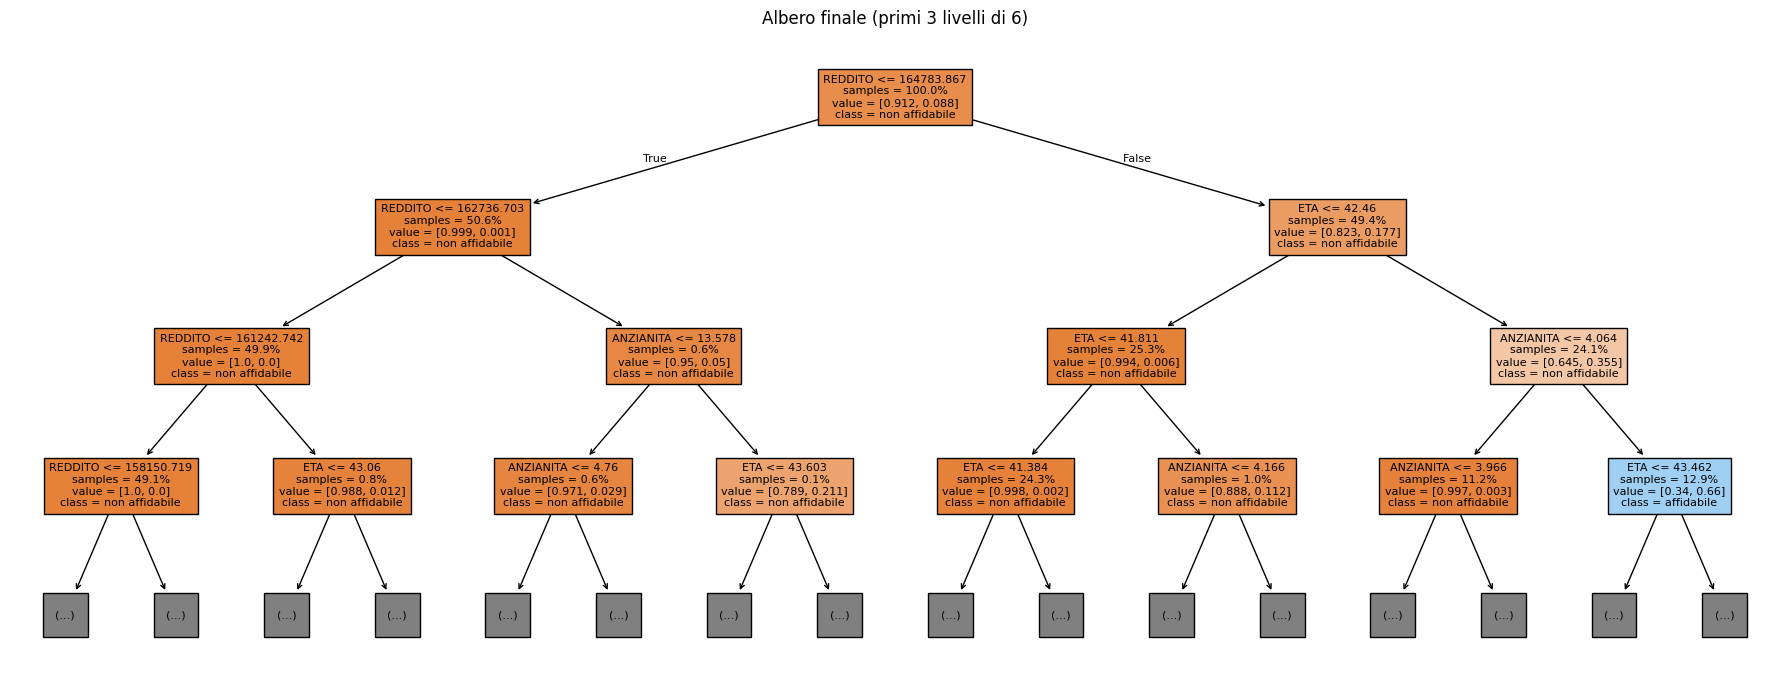

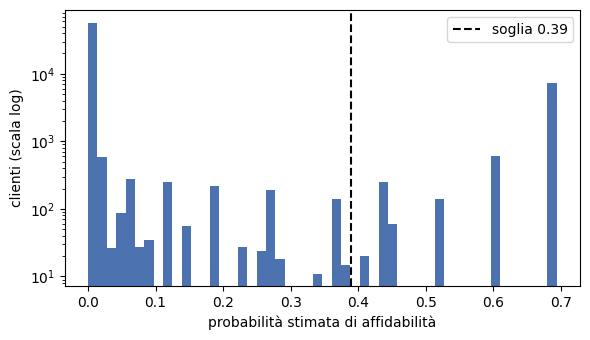

In [19]:
clf = final.named_steps['clf']; names = final.named_steps['prep'].get_feature_names_out()
print(export_text(clf, feature_names=list(names), decimals=1, show_weights=False))
plt.figure(figsize=(18, 7))
plot_tree(clf, feature_names=names, class_names=['non affidabile', 'affidabile'], filled=True, max_depth=3, fontsize=8, impurity=False, proportion=True)
plt.title(f'Albero finale (primi 3 livelli di {best_depth})'); plt.tight_layout()
plt.savefig(os.path.join(OUT, 'albero.png'), dpi=140); plt.show()

plt.figure(figsize=(6, 3.5))
plt.hist(p_te, bins=50, color='#4C72B0'); plt.yscale('log'); plt.axvline(SOGLIA, color='k', ls='--', label=f'soglia {SOGLIA:.2f}')
plt.xlabel('probabilità stimata di affidabilità'); plt.ylabel('clienti (scala log)'); plt.legend(); plt.tight_layout(); plt.show()

Le probabilità si dividono in due gruppi: vicine a **0** (clienti fuori dai requisiti, la grande maggioranza) e tra **0.5 e 0.7**
(clienti idonei). Nessun profilo supera circa il 70%: anche il cliente migliore, secondo questi dati, ha una probabilità su tre di non essere affidabile.
Per la banca questo si traduce in una politica a due fasce, più onesta di un unico "approvato/rifiutato":
- **Non idoneo**: almeno un requisito non è rispettato → rifiuto, con il motivo preciso;
- **Idoneo**: requisiti rispettati → probabilità tra 50% e 70%; la decisione finale richiede informazioni che il modello non ha
  (storico creditizio, documenti) oppure una scelta di rischio della banca.

## 6. Equità rispetto al genere
Il genere è escluso dal modello. Verifico comunque che le decisioni non penalizzino un genere (effetto indiretto tramite variabili correlate).

In [20]:
eq = pd.DataFrame({'genere': g_te, 'y': y_te, 'pred': pred})
tab = eq.groupby('genere').agg(clienti=('y', 'size'), affidabili_reali=('y', 'mean'), approvati_modello=('pred', 'mean'))
tab['recall (affidabili approvati)'] = eq[eq.y == 1].groupby('genere').pred.mean()
display(tab.style.format({'affidabili_reali': '{:.1%}', 'approvati_modello': '{:.1%}', 'recall (affidabili approvati)': '{:.1%}'}))

# Con il genere come variabile, cambierebbe qualcosa?
Xg_tr = X_tr.assign(GENERE_M=(g_tr == 'M').astype(int)); Xg_te = X_te.assign(GENERE_M=(g_te == 'M').astype(int))
pg = ColumnTransformer([('num', 'passthrough', NUM + BIN + ['GENERE_M']), ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False), CAT)])
mg = Pipeline([('prep', pg), ('clf', DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=50, random_state=SEED))]).fit(Xg_tr, y_tr)
print(f"PR AUC test con il genere: {average_precision_score(y_te, mg.predict_proba(Xg_te)[:, 1]):.4f} · senza: {test_metrics['PR AUC']:.4f}")

,clienti,affidabili_reali,approvati_modello,recall (affidabili approvati)
genere,,,,
F,45548,8.4%,11.8%,96.2%
M,22138,9.6%,13.6%,95.6%


PR AUC test con il genere: 0.6931 · senza: 0.6930


Le differenze tra i generi nelle approvazioni rispecchiano quelle già presenti nei dati (reddito e anzianità), e a parità di affidabilità reale
la recall è simile. Aggiungere il genere non migliora il modello: toglierlo non costa nulla e rende il sistema più difendibile.

## 7. Spiegare ogni decisione
Al posto delle feature importance globali (uguali per tutti), per ogni cliente si controllano i tre requisiti
e si indica **quale manca e di quanto**: è anche l'informazione che serve al cliente per sapere cosa cambiare.

In [21]:
ETICHETTE = {'REDDITO': 'Reddito annuo', 'ETA': 'Età', 'ANZIANITA': 'Anzianità lavorativa'}
UNITA = {'REDDITO': '', 'ETA': ' anni', 'ANZIANITA': ' anni'}

def fmt(col, v):
    return f'{v:,.0f}'.replace(',', '.') if col == 'REDDITO' else f'{v:.1f}{UNITA[col]}'

def valuta_cliente(cliente_raw, modello=final, soglia=SOGLIA, soglie=SOGLIE):
    # cliente_raw: dizionario con le colonne del CSV originale
    x = prepara(pd.DataFrame([cliente_raw]))
    p = float(modello.predict_proba(x)[0, 1])
    mancanti = [(c, x[c].iloc[0], soglie[c]) for c in soglie if x[c].iloc[0] < soglie[c]]
    esito = 'IDONEO' if (p >= soglia and not mancanti) else 'NON IDONEO'
    righe = [f'Esito: {esito} · probabilità di affidabilità stimata {p:.0%}']
    for c, v, s in mancanti:
        righe.append(f'- {ETICHETTE[c]}: {fmt(c, v)} sotto il requisito minimo di {fmt(c, s)}')
    if not mancanti and esito == 'NON IDONEO':
        righe.append('- Requisiti minimi rispettati, ma il profilo ricade in un gruppo con bassa affidabilità storica')
    if esito == 'IDONEO':
        righe.append(f'- Tutti i requisiti rispettati: tra i profili simili il {p:.0%} è risultato affidabile → verifica finale con lo storico creditizio')
    return esito, p, righe

for cliente in [data.iloc[i].drop(['ID', 'TARGET']).to_dict() for i in [0, 2, 5]]:
    print('\n'.join(valuta_cliente(cliente)[2]), '\n')

esempio = {'CODE_GENDER': 'M', 'FLAG_OWN_CAR': 'Y', 'FLAG_OWN_REALTY': 'Y', 'CNT_CHILDREN': 0, 'AMT_INCOME_TOTAL': 170000,
           'NAME_INCOME_TYPE': 'Working', 'NAME_EDUCATION_TYPE': 'Higher education', 'NAME_FAMILY_STATUS': 'Single / not married',
           'NAME_HOUSING_TYPE': 'House / apartment', 'DAYS_BIRTH': -19651, 'DAYS_EMPLOYED': -10000, 'FLAG_MOBIL': 1,
           'FLAG_WORK_PHONE': 0, 'FLAG_PHONE': 1, 'FLAG_EMAIL': 1, 'OCCUPATION_TYPE': 'Managers', 'CNT_FAM_MEMBERS': 1}
print('Cliente di esempio della versione precedente:'); print('\n'.join(valuta_cliente(esempio)[2]))

Esito: NON IDONEO · probabilità di affidabilità stimata 0%
- Età: 32.2 anni sotto il requisito minimo di 40.4 anni 

Esito: NON IDONEO · probabilità di affidabilità stimata 0%
- Reddito annuo: 110.959 sotto il requisito minimo di 156.891
- Anzianità lavorativa: 3.1 anni sotto il requisito minimo di 3.9 anni 

Esito: IDONEO · probabilità di affidabilità stimata 69%
- Tutti i requisiti rispettati: tra i profili simili il 69% è risultato affidabile → verifica finale con lo storico creditizio 

Cliente di esempio della versione precedente:
Esito: IDONEO · probabilità di affidabilità stimata 69%
- Tutti i requisiti rispettati: tra i profili simili il 69% è risultato affidabile → verifica finale con lo storico creditizio


## 8. Salvataggio

In [22]:
joblib.dump(final, os.path.join(OUT, 'credit_tree_pipeline.joblib'))
config = {'soglia': SOGLIA, 'soglie_requisiti': SOGLIE, 'profondita': best_depth, 'features': FEATURES,
          'NUM': NUM, 'BIN': BIN, 'CAT': CAT, 'categorie': {c: sorted(X_all[c].unique().tolist()) for c in CAT},
          'test': test_metrics, 'test_random_forest': {'ROC AUC': roc_auc_score(y_te, p_rf), 'PR AUC': average_precision_score(y_te, p_rf)}}
json.dump(config, open(os.path.join(OUT, 'config.json'), 'w'), indent=2, ensure_ascii=False)
import sklearn; print('sklearn', sklearn.__version__, '| salvato in', OUT, sorted(os.listdir(OUT)))

sklearn 1.6.1 | salvato in /content/drive/MyDrive/modelli_addestrati/credit_scoring ['albero.png', 'config.json', 'credit_tree_pipeline.joblib', 'cv_modelli.csv', 'target_vs_variabili.png']


## 9. Conclusioni

| Modello (test set, 67.686 clienti) | ROC AUC | PR AUC | Leggibile |
|---|---|---|---|
| Regressione logistica (CV) | 0.944 | 0.542 | sì |
| Random Forest, 300 alberi | 0.979 | 0.698 | no |
| **Albero decisionale, profondità 6** | **0.978** | **0.693** | **sì** |

**Il risultato principale non è un numero ma una scoperta sui dati.** L'affidabilità dipende prima di tutto da tre **requisiti minimi**
(reddito di circa 160 mila, età di circa 40 anni, almeno 4 anni di anzianità lavorativa): fuori da questi nel dataset non esiste nessun cliente affidabile.
Sopra le soglie l'effetto diventa graduale. Un singolo albero decisionale rappresenta questa struttura e raggiunge le stesse prestazioni
di una Random Forest da 300 alberi, con un vantaggio decisivo per una banca: **ogni decisione si può spiegare**.

**Cosa cambia rispetto alla prima versione**
- Stesse prestazioni (ROC AUC 0.978 contro 0.979), ma con un modello che un analista del credito può leggere e verificare.
- Le motivazioni del rifiuto sono **specifiche per ogni cliente** ("anzianità 3,1 anni sotto il requisito di 3,9") invece delle stesse tre feature per tutti.
- Il genere non è più una variabile del modello: toglierlo non costa nulla (PR AUC 0.6930 contro 0.6931), e i tassi di approvazione
  per genere seguono le differenze già presenti nei dati (recall 96% per le donne, 96% per gli uomini).
- Valutazione più solida: cross-validation, metriche adatte allo sbilanciamento, test set separato, soglia scelta sul validation.

**Limiti.** Tra i clienti che rispettano i requisiti il modello distingue solo in parte gli affidabili (ROC AUC 0.76 in quella zona)
e nessun profilo supera il 70% di probabilità: per quei casi la decisione finale richiede dati che qui mancano, come lo storico dei pagamenti.
La struttura a soglie così netta fa pensare a un'etichetta costruita con regole: su dati reali le prestazioni sarebbero più basse
e il monitoraggio nel tempo (deriva dei dati, verifica periodica dell'equità) sarebbe indispensabile.
